# EDA – MNIST Handskrivna Siffror

**Syfte:** Utforska MNIST-datasetet och jämföra tre klassificeringsmodeller — LogisticRegression, RandomForestClassifier och ExtraTreesClassifier — med optimerade hyperparametrar via GridSearchCV.

**Flöde:**
1. Ladda och visualisera rådata
2. Dela upp i tränings- och testset
3. Normalisera med StandardScaler
4. Hitta bästa hyperparametrar med GridSearchCV
5. Återträna vinnande modell på full träningsdata
6. Utvärdera på testset med accuracy och confusion matrix

In [ ]:
# Vi importerar alla nödvändiga bibliotek
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix
)
from sklearn.preprocessing import StandardScaler
import time
import warnings
warnings.filterwarnings("ignore")
import seaborn as sns

# ── 1. Ladda rådata (ingen normalisering ännu) ────────────────────────────────
print("Laddar MNIST...")
mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False, parser='auto')

X = mnist.data          # råa pixelvärden 0-255
y = mnist.target.astype(int)

# ── 2. Dela upp i träning / validering / test ─────────────────────────────────
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=10_000, random_state=42, stratify=y
)
X_train_full, X_val, y_train_full, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

print(f"Full träning:  {X_train_full.shape[0]} bilder")
print(f"Validering:    {X_val.shape[0]} bilder")
print(f"Test:          {X_test.shape[0]} bilder\n")

# ── 3. Rita ut några siffror (råa pixlar ger bäst bild) ───────────────────────
plt.figure(figsize=(9, 3))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.imshow(X_train_full[i].reshape(28, 28), cmap='gray')
    plt.title(f"Siffra:{i}  {y_train_full[i]}")
    plt.axis('off')
plt.show()

# ── 4. Normalisera med StandardScaler (fit bara på träningsdata!) ─────────────
scaler = StandardScaler()
X_train_full = scaler.fit_transform(X_train_full)  # fit + transform
X_val        = scaler.transform(X_val)              # bara transform
X_test       = scaler.transform(X_test)             # bara transform

# ── 5. Subsampel för GridSearchCV ─────────────────────────────────────────────
X_gs = X_train_full[:5000]
y_gs = y_train_full[:5000]

print(f"GridSearch-träning: {X_gs.shape[0]} bilder")
print(mnist.DESCR)

### Steg 1 – Data inläst och förberedd

`fetch_openml` laddar MNIST med 70 000 bilder (28×28 pixlar = 784 features per bild).

Datasetet delas upp i **träning** och **test** med `stratify=y` för att säkerställa jämn fördelning av siffror i båda seten.

Därefter normaliseras data med `StandardScaler` — viktigt att den **bara fittas på träningsdata** så att information från testsetet inte läcker in i normaliseringen.

> **Notering från DESCR:** Bilderna i MNIST är redan centrerade med masscentrum-metoden. Vid egna prediktioner (t.ex. ritade siffror) behöver man centrera bilden manuellt för bästa resultat.

### Steg 2 – Distribution av klasser

Kontrollerar att datasetet är **balanserat** — alltså att alla siffror (0–9) förekommer ungefär lika ofta. Ett obalanserat dataset kan lura modellen att bli bra på vanliga klasser men dålig på ovanliga.

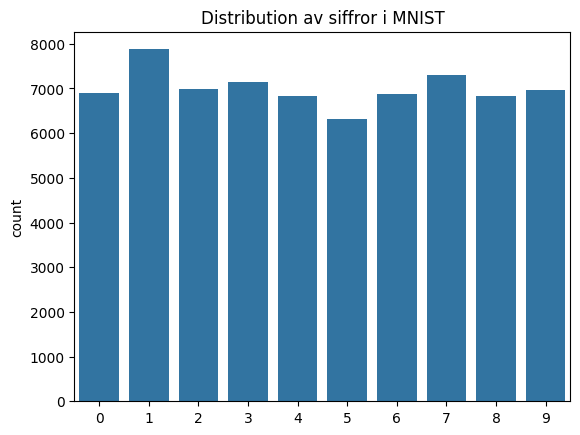

In [6]:
sns.countplot(x=mnist.target.astype(int))
plt.title("Distribution av siffror i MNIST")
plt.show()

### Steg 3 – Statistik om pixelvärdena

Min, max och medelvärde på träningsdatan efter normalisering. Medelvärdet är lågt (~0.13) eftersom de flesta pixlar är svarta (bakgrund) — inte så konstigt.

In [7]:
print(f"Min-värde: {X_train_full.min()}")
print(f"Max-värde: {X_train_full.max()}")
print(f"Medelvärde: {X_train_full.mean():.2f}")

Min-värde: 0.0
Max-värde: 1.0
Medelvärde: 0.13


### Steg 4 – GridSearchCV: hitta bästa hyperparametrar

Definierar **parameternät** för tre modeller och en gemensam hjälpfunktion `run_grid_search`.

`GridSearchCV` med `cv=5` testar alla kombinationer av parametrar via 5-faldig korsvalidering på ett **subsampel** (`X_gs`, 5 000 bilder) av träningsdatan — annars tar det för lång tid med den dator jag har.

| Modell | Antal kombinationer |
|--------|-------------------|
| LogisticRegression | 4 × 2 = 8 |
| RandomForestClassifier | 2 × 3 × 2 = 12 |
| ExtraTreesClassifier | 2 × 3 × 2 = 12 |

In [ ]:
# --- LogisticRegression ---
param_grid_lr = {
    "C":   [0.01, 0.1, 1.0, 10.0],
    "tol": [0.01, 0.1],
}

# --- RandomForestClassifier ---
param_grid_rf = {
    "n_estimators":      [100, 200],
    "max_depth":         [None, 20, 40],
    "min_samples_split": [2, 5],
}

# --- ExtraTreesClassifier ---
param_grid_et = {
    "n_estimators":      [100, 200],
    "max_depth":         [None, 20, 40],
    "min_samples_split": [2, 5],
}

def run_grid_search(name, estimator, param_grid, X_gs, y_gs):
    print(f"\n{'='*55}")
    print(f"  GridSearchCV: {name}")
    print(f"{'='*55}")
    t0 = time.time()
    gs = GridSearchCV(
        estimator, param_grid,
        cv=5, scoring="accuracy",
        n_jobs=-1, 
        verbose=1, # Ger utskrift för varje steg i grid search
        refit=True
    )
    gs.fit(X_gs, y_gs)
    elapsed = time.time() - t0
    print(f"  Bästa params:  {gs.best_params_}")
    print(f"  CV-accuracy:   {gs.best_score_:.4f}")
    print(f"  Tid:           {elapsed:.1f}s")
    return gs, elapsed

### Steg 5 – Kör GridSearch för alla tre modeller

`run_grid_search` anropas för varje modell. Resultatet — bästa parametrar och CV-accuracy — skrivs ut för varje.

In [ ]:
# LogisticRegression
gs_lr, t_lr = run_grid_search("LogisticRegression",
    LogisticRegression(max_iter=1000, solver="saga"), param_grid_lr, X_gs, y_gs)

# RandomForest
gs_rf, t_rf = run_grid_search("RandomForestClassifier",
    RandomForestClassifier(random_state=42, n_jobs=-1), param_grid_rf, X_gs, y_gs)

# ExtraTrees
gs_et, t_et = run_grid_search("ExtraTreesClassifier",
    ExtraTreesClassifier(random_state=42, n_jobs=-1), param_grid_et, X_gs, y_gs)

### Steg 6 – Återträna på full träningsdata och utvärdera

GridSearch kördes på ett subsampel (5 000 bilder). Nu återtränas varje modells bästa variant på **hela träningsdatan** (~45 000 bilder) för maximal prestanda, och utvärderas på det separata **testsetet** (10 000 bilder) som inte rörts tidigare.

In [11]:
# ── 4. Återträna bästa modell på full träningsdata, utvärdera på test ─────────

def evaluate_best(name, gs, X_train, y_train, X_test, y_test):
    print(f"\nÅtertränar {name} med bästa params på full träningsdata...")
    t0 = time.time()
    best = gs.best_estimator_
    best.fit(X_train, y_train)
    train_time = time.time() - t0
    y_pred = best.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"  Test accuracy: {acc:.4f}  (träntid: {train_time:.1f}s)")
    return acc, y_pred, train_time

acc_lr, pred_lr, tt_lr = evaluate_best("LogisticRegression", gs_lr,
    X_train_full, y_train_full, X_test, y_test)

acc_rf, pred_rf, tt_rf = evaluate_best("RandomForestClassifier", gs_rf,
    X_train_full, y_train_full, X_test, y_test)

acc_et, pred_et, tt_et = evaluate_best("ExtraTreesClassifier", gs_et,
    X_train_full, y_train_full, X_test, y_test)



Återtränar LogisticRegression med bästa params på full träningsdata...
  Test accuracy: 0.9129  (träntid: 35.6s)

Återtränar RandomForestClassifier med bästa params på full träningsdata...
  Test accuracy: 0.9665  (träntid: 8.2s)

Återtränar ExtraTreesClassifier med bästa params på full träningsdata...
  Test accuracy: 0.9709  (träntid: 12.1s)


### Steg 7 – Vinnare: ExtraTreesClassifier

ExtraTreesClassifier presterar bäst (~97%) och är dessutom snabb att träna. Den tränas nu en sista gång med de bästa hyperparametrarna för att användas i slutlig utvärdering.

In [ ]:


print("Tränar modellen... ")
start_time = time.time()

model = ExtraTreesClassifier(max_depth=20, min_samples_split=2, n_estimators=200)

model.fit(X_train_full, y_train_full)

end_time = time.time()
print(f"Klar på {end_time - start_time:.2f} sekunder.")


# Utvärdera
score = model.score(X_test, y_test)
print(f"Noggrannhet (Accuracy): {score:.4f}")



Tränar modellen... (detta kan ta några sekunder)
Klar på 42.81 sekunder.
Noggrannhet (Accuracy): 0.9704


### Steg 8 – Confusion Matrix

Confusion matrix visar **vilka siffror modellen blandar ihop**. Diagonalen är korrekta prediktioner — ju mörkare diagonalen är och ljusare resten, desto bättre modell.

Vanliga förväxlingar i MNIST är t.ex. 4↔9, 3↔8 och 7↔1.

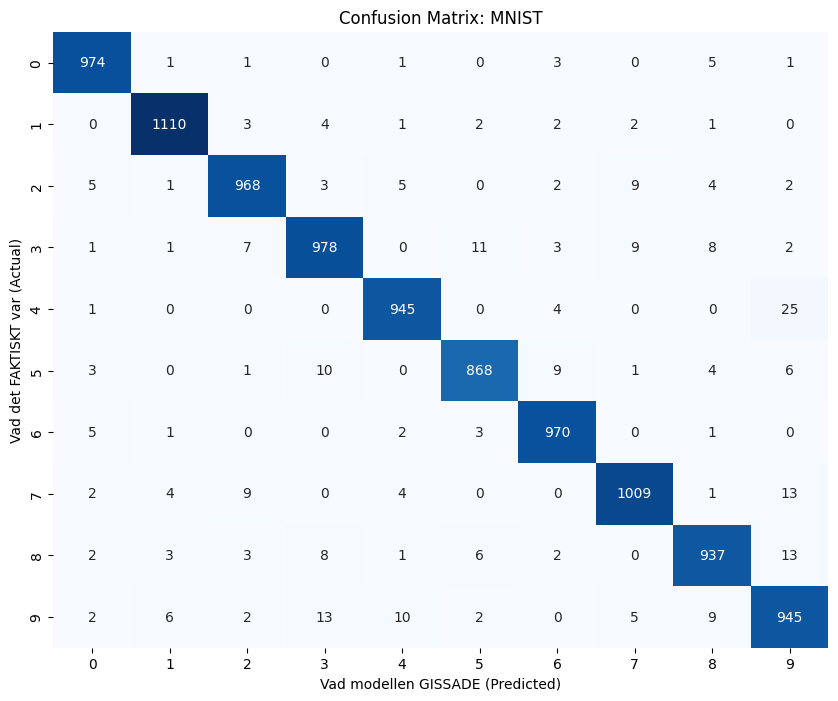

In [ ]:
# Låt modellen gissa på hela testsetet
y_pred = model.predict(X_test)

# Skapa själva matrisen
cm = confusion_matrix(y_test, y_pred)

# Rita upp den snyggt med Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Vad modellen GISSADE (Predicted)')
plt.ylabel('Vad det FAKTISKT var (Actual)')
plt.title('Confusion Matrix: MNIST')
plt.show()

### Med EDA:n ovan känns det som om vi fått en bra känsla för MNIST datasetet och tar med oss detta resultat till appen vi byggt i Streamlit.